In [ ]:
pip install yfinance

In [ ]:
from datetime import time
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

# Calculate end date = present date - 2 years
end_date = datetime.today() - timedelta(days=365*2)

start_date = "2000-01-01"

# Ask user number of shares
n = int(input("Enter number of shares (min 3, max 10): "))

while n < 3 or n > 10:
    n = int(input("Invalid input. Enter number between 3 and 10: "))

tickers = []

# Take ticker input
for i in range(n):
    ticker = input(f"Enter ticker {i+1} (example: PFC.NS): ")
    tickers.append(ticker)

# Dictionary to store share data
shares = {}

# Download data
for i, ticker in enumerate(tickers, start=1):

    data = yf.download(
        tickers=ticker,
        start=start_date,
        end=end_date.strftime("%Y-%m-%d"),
        interval="1d"
    ).dropna()

    # Save as share1, share2, share3...
    shares[f"share{i}"] = data

    # Also create variable names dynamically
    globals()[f"share{i}"] = data

print("\nData downloaded for:")
for key in shares:
    print(key)

Enter number of shares (min 3, max 10): 4
Enter ticker 1 (example: PFC.NS): ^BSESN
Enter ticker 2 (example: PFC.NS): ^NSEI
Enter ticker 3 (example: PFC.NS): AAPL
Enter ticker 4 (example: PFC.NS): RELIANCE.NS


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data downloaded for:
share1
share2
share3
share4


In [ ]:
# Display first few rows of each share dataset
for name, data in shares.items():
    print(f"\n{name}")
    display(data.head())


share1


Price,Close,High,Low,Open,Volume
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
Date,,,,,
2000-01-03,5375.109863,5384.660156,5209.540039,5209.540039,0
2000-01-04,5491.009766,5533.979980,5376.430176,5533.979980,0
2000-01-05,5357.000000,5464.350098,5184.479980,5265.089844,0
2000-01-06,5421.529785,5489.859863,5391.330078,5424.209961,0
2000-01-07,5414.479980,5463.250000,5330.580078,5358.279785,0



share2


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0



share3


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2000-01-03,0.838496,0.842709,0.761716,0.785592,535796800
2000-01-04,0.767803,0.828664,0.757971,0.810874,512377600
2000-01-05,0.779037,0.828196,0.771547,0.777165,778321600
2000-01-06,0.711621,0.801510,0.711621,0.794956,767972800
2000-01-07,0.745330,0.756566,0.715367,0.722858,460734400



share4


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2000-01-03,13.244408,13.244408,12.497206,12.497206,62409578
2000-01-04,14.304695,14.304695,13.223358,13.596958,132872110
2000-01-05,14.865095,15.149242,13.504873,13.504873,375789847
2000-01-06,15.488641,15.822778,15.207126,15.207126,219621124
2000-01-07,16.551559,16.727837,15.417603,15.522843,278281260


In [ ]:
for name, data in shares.items():
    data["Change"] = ((data["Close"] - data["Open"]) / data["Open"]) * 100

In [ ]:
# Display first few rows of each share dataset
for name, data in shares.items():
    print(f"\n{name}")
    display(data.head())


share1


Price,Close,High,Low,Open,Volume,Change
Ticker,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN,
Date,,,,,,
2000-01-03,5375.109863,5384.660156,5209.540039,5209.540039,0,3.178204
2000-01-04,5491.009766,5533.979980,5376.430176,5533.979980,0,-0.776479
2000-01-05,5357.000000,5464.350098,5184.479980,5265.089844,0,1.745652
2000-01-06,5421.529785,5489.859863,5391.330078,5424.209961,0,-0.049411
2000-01-07,5414.479980,5463.250000,5330.580078,5358.279785,0,1.048848



share2


Price,Close,High,Low,Open,Volume,Change
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,
Date,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,-0.526736
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,1.159300
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,4.001980
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,0.268218
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,1.779939



share3


Price,Close,High,Low,Open,Volume,Change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2000-01-03,0.838496,0.842709,0.761716,0.785592,535796800,6.734199
2000-01-04,0.767803,0.828664,0.757971,0.810874,512377600,-5.311745
2000-01-05,0.779037,0.828196,0.771547,0.777165,778321600,0.240950
2000-01-06,0.711621,0.801510,0.711621,0.794956,767972800,-10.482987
2000-01-07,0.745330,0.756566,0.715367,0.722858,460734400,3.108838



share4


Price,Close,High,Low,Open,Volume,Change
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,
Date,,,,,,
2000-01-03,13.244408,13.244408,12.497206,12.497206,62409578,5.978954
2000-01-04,14.304695,14.304695,13.223358,13.596958,132872110,5.205115
2000-01-05,14.865095,15.149242,13.504873,13.504873,375789847,10.072087
2000-01-06,15.488641,15.822778,15.207126,15.207126,219621124,1.851203
2000-01-07,16.551559,16.727837,15.417603,15.522843,278281260,6.627116


In [ ]:
for name in shares:
    shares[name] = shares[name][["Close", "Change"]]
    globals()[name] = shares[name]

In [ ]:
for name, s in shares.items():
    while hasattr(s.columns, "levels") and len(s.columns.levels) > 1:
        s.columns = s.columns.droplevel(1)
    shares[name] = s
    globals()[name] = s

In [ ]:
for name in shares:
    shares[name] = shares[name].reset_index()
    globals()[name] = shares[name]

In [ ]:
for name, s in shares.items():
    s.columns.name = None
    globals()[name] = s

In [ ]:
# Standardizing date formats across all datasets
for i, (name, df) in enumerate(shares.items()):

    if i == 1:  # equivalent to share2
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
    else:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    shares[name] = df


# Checking for missing values in each dataset
missing_values = {
    f"Share{i+1}": df.isnull().sum()
    for i, df in enumerate(shares.values())
}

missing_values_df = (
    pd.DataFrame(missing_values)
    .rename_axis("Column")
)

missing_values_df

,Share1,Share2,Share3,Share4
Column,,,,
Date,0,0,0,0
Close,0,0,0,0
Change,0,0,0,0


In [ ]:
# standardizing date formats across all datasets
date_cols = ["Date"]

for df in shares.values():
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")


# aligning datasets by date to ensure they cover the same date range
common_start_date = max(df["Date"].min() for df in shares.values())
common_end_date   = min(df["Date"].max() for df in shares.values())


# printing common start and end dates
common_start_date, common_end_date

(Timestamp('2007-09-17 00:00:00'), Timestamp('2024-03-11 00:00:00'))

In [ ]:
start_date = common_start_date
end_date = common_end_date

for name in shares:
    shares[name] = shares[name][
        (shares[name]["Date"] >= start_date) &
        (shares[name]["Date"] <= end_date)
    ]
    globals()[name] = shares[name]

In [ ]:
for name in shares:
    shares[name] = shares[name].reset_index(drop=True)
    globals()[name] = shares[name]

In [ ]:
# create Daily Return column for all shares
for df in shares.values():
    df["Daily Return"] = df["Change"]

# display first rows to confirm
for name, df in shares.items():
    print(name)
    display(df[["Date", "Daily Return"]].head())

share1


,Date,Daily Return
0,2007-09-17,-1.023385
1,2007-09-18,0.785034
2,2007-09-19,2.396117
3,2007-09-20,0.039166
4,2007-09-21,1.295903


share2


,Date,Daily Return
0,2007-09-17,-0.526736
1,2007-09-18,1.159300
2,2007-09-19,4.001980
3,2007-09-20,0.268218
4,2007-09-21,1.779939


share3


,Date,Daily Return
0,2007-09-17,-0.417315
1,2007-09-18,1.337535
2,2007-09-19,-1.573205
3,2007-09-20,0.114166
4,2007-09-21,2.132636


share4


,Date,Daily Return
0,2007-09-17,-0.083748
1,2007-09-18,1.883666
2,2007-09-19,1.822012
3,2007-09-20,0.657169
4,2007-09-21,4.416214


In [ ]:
# calculating average annual return and annualized volatility for each asset

trading_days = 252

# average annual return
avg_annual_return = {
    name.upper(): df["Daily Return"].mean() * trading_days
    for name, df in shares.items()
}

# annualized volatility
annualized_volatility = {
    name.upper(): df["Daily Return"].std() * (trading_days ** 0.5)
    for name, df in shares.items()
}

# combine metrics into dataframe
metrics_df = pd.DataFrame({
    "Average Annual Return": avg_annual_return,
    "Annualized Volatility": annualized_volatility
})

metrics_df

,Average Annual Return,Annualized Volatility
SHARE1,-22.515759,18.064222
SHARE2,-13.307055,19.491108
SHARE3,8.422370,25.382291
SHARE4,-22.596677,29.791943


In [ ]:
!pip install gym

In [ ]:
import gym
import numpy as np
import pandas as pd
from gym import spaces


class TradingEnv(gym.Env):
    def __init__(self, historical_data, initial_balance=10000):
        super().__init__()
        self.historical_data = historical_data
        self.initial_balance = initial_balance
        self.n_assets = len(historical_data.columns)
        self.current_step = 0
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2 * self.n_assets,), dtype=np.float32)
        self.reset()

    def reset(self):
        self.current_step = 0
        self.current_date = self.historical_data.index[self.current_step]
        self.portfolio_allocations = np.array([1.0 / self.n_assets] * self.n_assets)
        self.portfolio_value = self.initial_balance
        return self._construct_state()


    def _construct_state(self):
        #simplified state includes historical returns
        historical_returns = self.historical_data.iloc[self.current_step].values
        state = np.concatenate([historical_returns, self.portfolio_allocations])
        return state

    def step(self, action):
        action = self._normalize_action(action)
        prev_portfolio_value = self.portfolio_value
        self.portfolio_value = self._calculate_portfolio_value(action)
        reward = self.portfolio_value - prev_portfolio_value
        self.current_step += 1
        done = self.current_step >= len(self.historical_data) - 1
        self.current_date = self.historical_data.index[min(self.current_step, len(self.historical_data) - 1)]

        #call render() method after each step
        self.render()

        #construct the state with the correct shape
        state = self._construct_state()
        return state, reward, done, {}

    def _normalize_action(self, action):
        normalized_action = np.clip(action, 0, 1)
        normalized_action /= np.sum(normalized_action)
        return normalized_action

    def _calculate_portfolio_value(self, action):
        asset_prices = self.historical_data.iloc[self.current_step, :self.n_assets].values
        self.portfolio_allocations = action
        return np.dot(asset_prices, action) * self.portfolio_value

    def render(self, mode='human'):
        print(f"Step: {self.current_step}")
        print(f"Date: {self.current_date}")
        print(f"Allocations: {self.portfolio_allocations}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
from stable_baselines3 import DDPG, PPO
from stable_baselines3.common.noise import NormalActionNoise
import numpy as np
from stable_baselines3.common.policies import ActorCriticPolicy
from torch.nn import BatchNorm1d


class DRLAgent:
    """A DRL agent for portfolio management using DDPG or PPO."""

    def __init__(self, env, algorithm='DDPG',noise_decay=0.99, noise_sigma=0.1):
        self.env = env
        self.algorithm = algorithm
        self.noise_decay = noise_decay
        self.noise_sigma = noise_sigma

        #define the action noise for DDPG
        self.n_actions = env.action_space.shape[-1]
        self.action_noise = NormalActionNoise(mean=np.zeros(self.n_actions), sigma=self.noise_sigma * np.ones(self.n_actions))

        #initialize the model based on the selected algorithm
        policy_kwargs = dict(net_arch=dict(pi=[128, 128], qf=[400, 300]))
        if algorithm == 'DDPG':
            self.model = DDPG("MlpPolicy", env, action_noise=self.action_noise, verbose=1, learning_rate=0.001, policy_kwargs=policy_kwargs)
        elif algorithm == 'PPO':
            self.model = PPO("MlpPolicy", env, verbose=1)
        else:
            raise ValueError("Unsupported algorithm. Choose 'DDPG' or 'PPO'.")

    def train(self, total_timesteps=10000):
        """Train the agent."""
        self.model.learn(total_timesteps=total_timesteps)
        #reducing the noise after training
        self.noise_sigma *= self.noise_decay
        self.action_noise = NormalActionNoise(mean=np.zeros(self.n_actions), sigma=self.noise_sigma * np.ones(self.n_actions))

    def act(self, observation):
        """Determine the action based on the current observation."""
        action, _states = self.model.predict(observation, deterministic=True)
        return action

    def save(self, path):
        """Save the model."""
        self.model.save(path)

    def load(self, path):
        """Load the model."""
        self.model = self.model.load(path)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ensure no NaN values remain in the datasets
for name, df in shares.items():
    assert not df.isnull().any().any(), f"NaN values found in {name}"

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# preparing the combined historical data DataFrame
historical_data = pd.concat(
    [
        df.set_index("Date")["Daily Return"].rename(f"Share{i+1}")
        for i, df in enumerate(shares.values())
    ],
    axis=1,
    join="inner"
)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def safe_set_index(df, column_name="Date"):
    if column_name in df.columns:
        df[column_name] = pd.to_datetime(df[column_name])
        df.set_index(column_name, inplace=True)

# applying safe_set_index to all datasets
for df in shares.values():
    safe_set_index(df)

# combining Close prices dynamically
historic_data = pd.concat(
    [
        df[["Close"]].rename(columns={"Close": f"Share{i+1}"})
        for i, df in enumerate(shares.values())
    ],
    axis=1,
    join="inner"
)

historic_data

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Share1,Share2,Share3,Share4
Date,,,,
2007-09-17,15504.429688,4494.649902,4.147180,203.714249
2007-09-18,15669.120117,4546.200195,4.222388,206.702194
2007-09-19,16322.750000,4732.350098,4.217891,218.337753
2007-09-20,16347.950195,4747.549805,4.204110,219.984879
2007-09-21,16564.230469,4837.549805,4.319168,229.039169
...,...,...,...,...
2024-03-04,73872.289062,22405.599609,173.520844,1496.325073
2024-03-05,73677.132812,22356.300781,168.585693,1489.177979
2024-03-06,74085.992188,22474.050781,167.594742,1491.957275


In [ ]:
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(historic_data)

#converting the normalized array back to a DataFrame
historical_data = pd.DataFrame(normalized_data, columns=historic_data.columns, index=historic_data.index)

#fill any NaN values that might result from the concatenation
#forward fill carries forward the last known value, and backfill fills backwards
historical_data.fillna(method='ffill', inplace=True)
historical_data.fillna(method='bfill', inplace=True)  #in case the first rows contain NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# function to safely set Date as index
def safe_set_index(df, column_name="Date"):
    if column_name in df.columns:
        df[column_name] = pd.to_datetime(df[column_name])
        df.set_index(column_name, inplace=True)

# apply to all datasets dynamically
for df in shares.values():
    safe_set_index(df)

# combine Close prices dynamically
historic_data = pd.concat(
    [
        df[["Close"]].rename(columns={"Close": f"Share{i+1}"})
        for i, df in enumerate(shares.values())
    ],
    axis=1,
    join="inner"
)

# normalize prices
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(historic_data)

# convert back to DataFrame
historical_data = pd.DataFrame(
    normalized_data,
    columns=historic_data.columns,
    index=historic_data.index
)

# handle missing values
historical_data.ffill(inplace=True)
historical_data.bfill(inplace=True)

print(historical_data.head())
print(historical_data.isnull().any())

              Share1    Share2    Share3    Share4
Date                                              
2007-09-17  0.111342  0.098674  0.009312  0.072328
2007-09-18  0.113839  0.101255  0.009701  0.074472
2007-09-19  0.123749  0.110577  0.009677  0.082822
2007-09-20  0.124131  0.111338  0.009606  0.084005
2007-09-21  0.127410  0.115845  0.010200  0.090503
Share1    False
Share2    False
Share3    False
Share4    False
dtype: bool


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip install shimmy

In [ ]:
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from gym import spaces


In [ ]:
#creating the environment
env = TradingEnv(historical_data, initial_balance=10000)

In [ ]:
#initializing the DRL agent
agent = DRLAgent(env, algorithm='DDPG')
print(env.observation_space)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Box(-inf, inf, (8,), float32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
#training the agent
agent.train(total_timesteps=5000)

Streaming output truncated to the last 5000 lines.
Date: 2021-09-14 00:00:00
Allocations: [0.3281326  0.         0.33593372 0.33593372]
Step: 3335
Date: 2021-09-15 00:00:00
Allocations: [0.3274808  0.         0.32990983 0.34260935]
Step: 3336
Date: 2021-09-16 00:00:00
Allocations: [0.33067393 0.00797814 0.33067393 0.33067393]
Step: 3337
Date: 2021-09-17 00:00:00
Allocations: [0.33746913 0.         0.32506168 0.33746913]
Step: 3338
Date: 2021-09-20 00:00:00
Allocations: [0.33656192 0.         0.32687616 0.33656192]
Step: 3339
Date: 2021-09-21 00:00:00
Allocations: [0.3400477  0.         0.31990466 0.3400477 ]
Step: 3340
Date: 2021-09-22 00:00:00
Allocations: [0.33464724 0.00786718 0.32717788 0.33030772]
Step: 3341
Date: 2021-09-23 00:00:00
Allocations: [0.34409943 0.         0.32727337 0.3286272 ]
Step: 3342
Date: 2021-09-24 00:00:00
Allocations: [0.3361157  0.00242871 0.32533994 0.3361157 ]
Step: 3343
Date: 2021-09-27 00:00:00
Allocations: [0.34193116 0.01483264 0.34193116 0.301305  ]


In [ ]:
#saving the trained model
agent.save("ddpg_portfolio_management")
# If needed, you can load the model from the file
agent.load("ddpg_portfolio_management")

In [ ]:
#reset the environment to get the initial state and use the agent to decide the action
observation = env.reset()
action = agent.act(observation)
print("Action taken:", action)

Action taken: [0.0000000e+00 9.9999994e-01 5.9604645e-08 2.9802322e-08]


# one go code

In [ ]:
'''# 'historical_data' is a DataFrame that includes the historical prices for the assets
#this must be preprocessed to align the dates and include only relevant columns before this step
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from gym import spaces


#creating the environment
env = TradingEnv(historical_data, initial_balance=10000)

#initializing the DRL agent
agent = DRLAgent(env, algorithm='DDPG')
print(env.observation_space)

#training the agent
agent.train(total_timesteps=5000)

#saving the trained model
agent.save("ddpg_portfolio_management")
# If needed, you can load the model from the file
agent.load("ddpg_portfolio_management")

#reset the environment to get the initial state and use the agent to decide the action
observation = env.reset()
action = agent.act(observation)
print("Action taken:", action)'''

Streaming output truncated to the last 5000 lines.
Allocations: [0.3258108  0.33044595 0.33891127 0.00483204]
Step: 3335
Date: 2021-09-15 00:00:00
Allocations: [0.33162704 0.32877606 0.31792116 0.02167568]
Step: 3336
Date: 2021-09-16 00:00:00
Allocations: [0.32207754 0.30739054 0.3317512  0.03878075]
Step: 3337
Date: 2021-09-17 00:00:00
Allocations: [0.33333334 0.33333334 0.33333334 0.        ]
Step: 3338
Date: 2021-09-20 00:00:00
Allocations: [0.3327492  0.33019063 0.31200534 0.02505486]
Step: 3339
Date: 2021-09-21 00:00:00
Allocations: [0.33111277 0.33111277 0.32841828 0.00935612]
Step: 3340
Date: 2021-09-22 00:00:00
Allocations: [0.3080895  0.33065984 0.33065984 0.03059085]
Step: 3341
Date: 2021-09-23 00:00:00
Allocations: [0.31904382 0.33617854 0.33617854 0.00859908]
Step: 3342
Date: 2021-09-24 00:00:00
Allocations: [0.3305971  0.3305971  0.3305971  0.00820866]
Step: 3343
Date: 2021-09-27 00:00:00
Allocations: [0.33917567 0.33691612 0.32390824 0.        ]
Step: 3344
Date: 2021-09-2

In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

# date range
end_date = datetime.today() - timedelta(days=10)
start_date = datetime.today() - timedelta(days=365*2)

# dictionary to store test data
test_shares = {}

for i, ticker in enumerate(tickers, start=1):

    data = yf.download(
        tickers=ticker,
        start=start_date.strftime("%Y-%m-%d"),
        end=end_date.strftime("%Y-%m-%d"),
        interval="1d"
    ).dropna()

    test_shares[f"share{i}_test_data"] = data
    globals()[f"share{i}_test_data"] = data

print("Downloaded test datasets:")
print(test_shares.keys())

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent d

Downloaded test datasets:
dict_keys(['share1_test_data', 'share2_test_data', 'share3_test_data', 'share4_test_data'])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for name, df in test_shares.items():
    df["Change"] = ((df["Close"] - df["Open"]) / df["Open"]) * 100
    globals()[name] = df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for name in test_shares:
    test_shares[name] = test_shares[name][["Close", "Change"]]
    globals()[name] = test_shares[name]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for name, s in test_shares.items():
    while hasattr(s.columns, "levels") and len(s.columns.levels) > 1:
        s.columns = s.columns.droplevel(1)
    test_shares[name] = s
    globals()[name] = s

In [ ]:
for name in test_shares:
    test_shares[name] = test_shares[name].reset_index()
    globals()[name] = test_shares[name]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for name, df in test_shares.items():
    df.columns.name = None
    globals()[name] = df

In [ ]:
# standardizing date formats across all datasets
for df in test_shares.values():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# checking for missing values in each dataset
missing_values = {
    name: df.isnull().sum()
    for name, df in test_shares.items()
}

missing_values_df = (
    pd.DataFrame(missing_values)
    .rename_axis("Column")
)

missing_values_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,share1_test_data,share2_test_data,share3_test_data,share4_test_data
Column,,,,
Date,0,0,0,0
Close,0,0,0,0
Change,0,0,0,0


In [ ]:
# standardizing date formats across all datasets
date_cols = ["Date"]

for df in test_shares.values():
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")


# aligning datasets by date to ensure they cover the same date range
common_start_date = max(df["Date"].min() for df in test_shares.values())
common_end_date   = min(df["Date"].max() for df in test_shares.values())


# printing common start and end dates
common_start_date, common_end_date

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(Timestamp('2024-03-12 00:00:00'), Timestamp('2026-02-27 00:00:00'))

In [ ]:
start_date = common_start_date
end_date = common_end_date

for name in test_shares:
    test_shares[name] = test_shares[name][
        (test_shares[name]["Date"] >= start_date) &
        (test_shares[name]["Date"] <= end_date)
    ]
    globals()[name] = test_shares[name]

In [ ]:
# create Daily Return column for all test datasets
for df in test_shares.values():
    df["Daily Return"] = df["Change"]

# display first rows to confirm
for name, df in test_shares.items():
    print(name)
    display(df[["Date", "Daily Return"]].head())

share1_test_data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,Daily Return
0,2024-03-12,0.206130
1,2024-03-13,-1.664348
2,2024-03-14,0.726442
3,2024-03-15,-0.333865
4,2024-03-18,0.221974


share2_test_data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,Daily Return
0,2024-03-12,0.046204
1,2024-03-13,-0.949238
2,2024-03-14,0.052048
3,2024-03-15,0.847109
4,2024-03-18,-1.053714


share4_test_data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Date,Daily Return
0,2024-03-12,0.601737
1,2024-03-13,-3.216704
2,2024-03-14,-0.571298
3,2024-03-15,-0.541742
4,2024-03-18,1.371477


In [ ]:
for name, df in test_shares.items():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    globals()[name] = df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
for name, df in test_shares.items():
    df.set_index("Date", inplace=True)
    globals()[name] = df

In [ ]:
shares_list = list(test_shares.values())

portfolio = sum(
    action[i] * shares_list[i]["Close"]
    for i in range(len(shares_list))
)

In [ ]:
pip install quantstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
import quantstats as qs
qs.stats.sharpe(portfolio)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


np.float64(0.3802324740294653)

In [ ]:
from datetime import datetime, timedelta
import quantstats as qs

stock = qs.utils.download_returns("^NSEI")

end_date = datetime.today() - timedelta(days=10)
start_date = datetime.today() - timedelta(days=365*2)

stock = stock.loc[start_date:end_date]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


                 Parameters
----------------------------------------
Benchmark                      BENCHMARK
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes
Match Dates                          Yes

[Performance Metrics]



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2024-03-14   2024-03-14
End Period                 2026-02-27   2026-02-27
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          14.46%       12.43%
CAGR﹪                     7.56%        6.53%

Sharpe                     0.62         0.55
Prob. Sharpe Ratio         79.83%       77.19%
Smart Sharpe               0.57         0.51
Sortino                    0.89         0.79
Smart Sortino              0.82         0.74
Sortino/√2                 0.63         0.56
Smart Sortino/√2           0.58         0.52
Omega                      1.12         1.1

Max Drawdown               -15.77%      -15.11%
Max DD Date                2025-03-04   2025

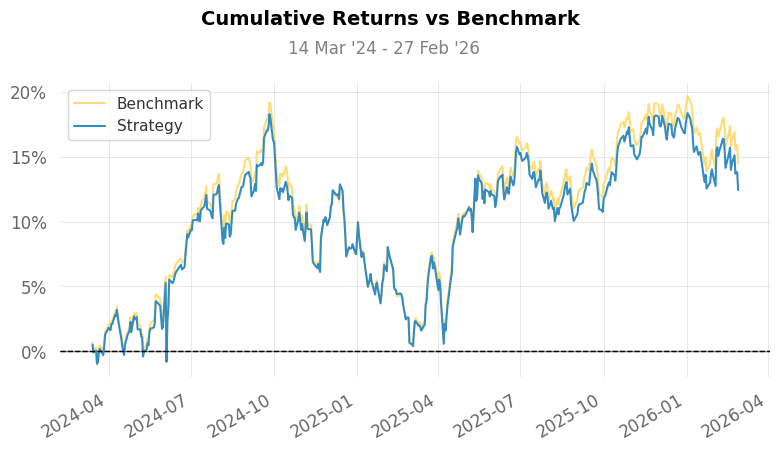

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


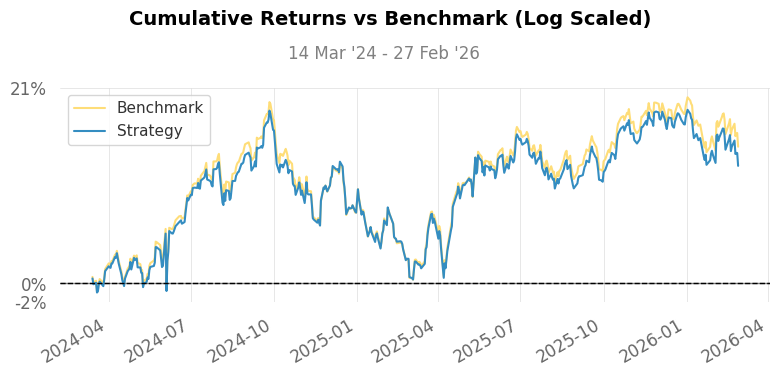

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


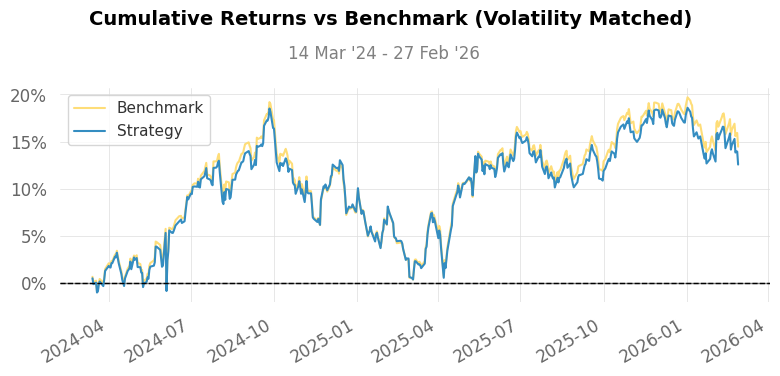

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


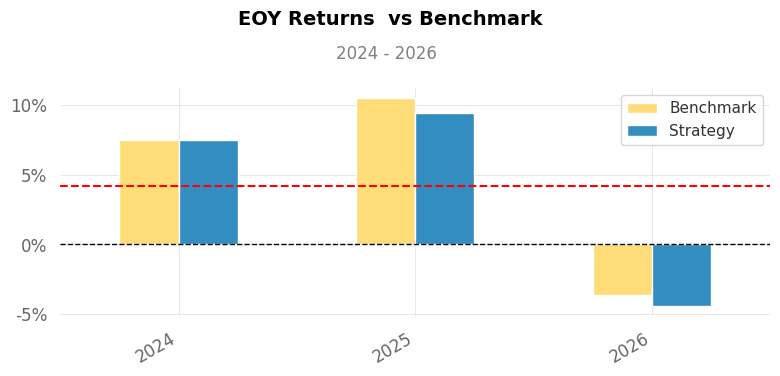

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


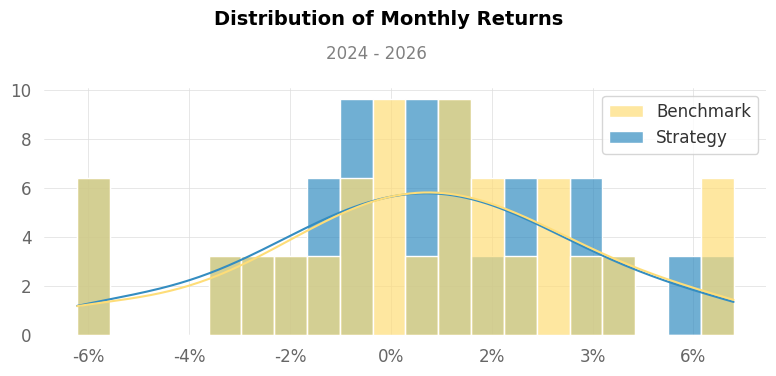

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


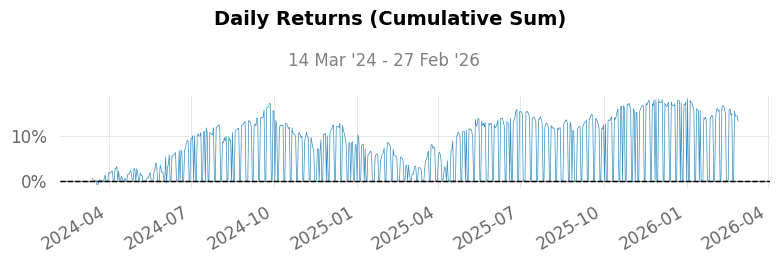

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


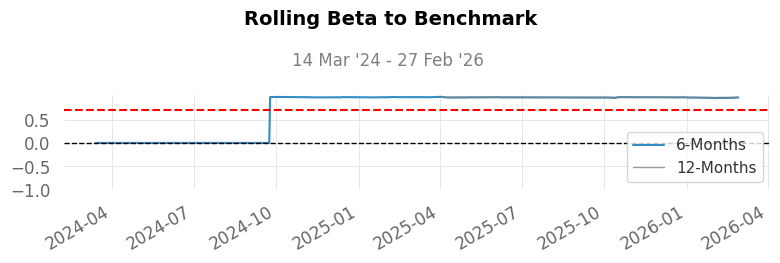

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


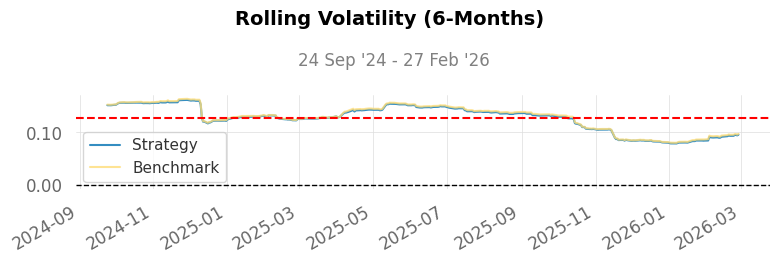

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


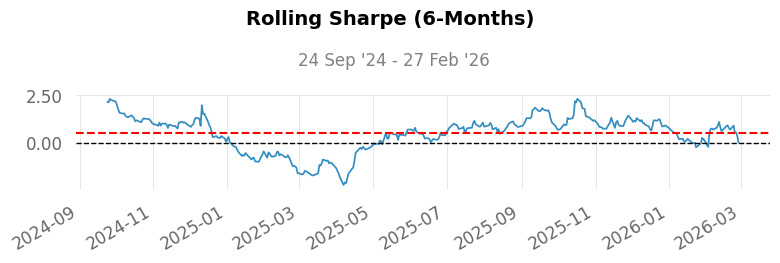

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


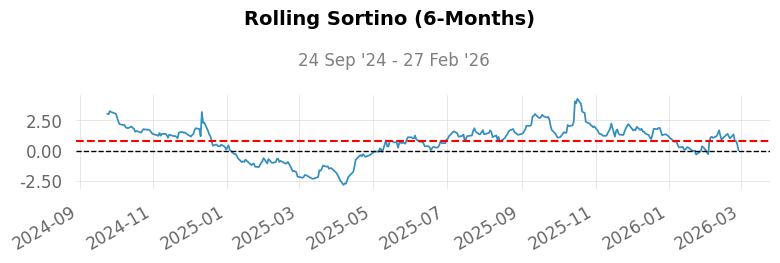

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


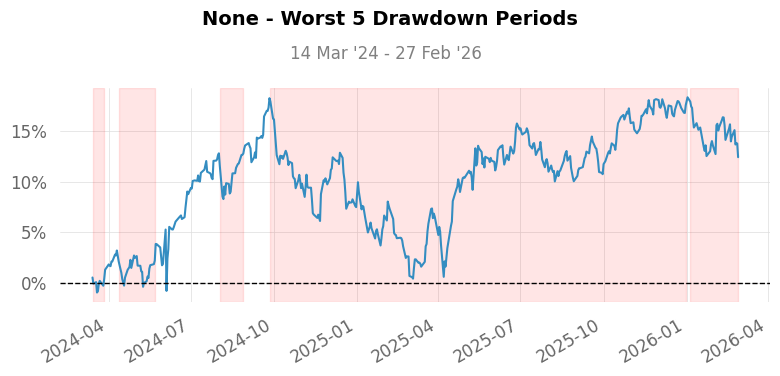

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


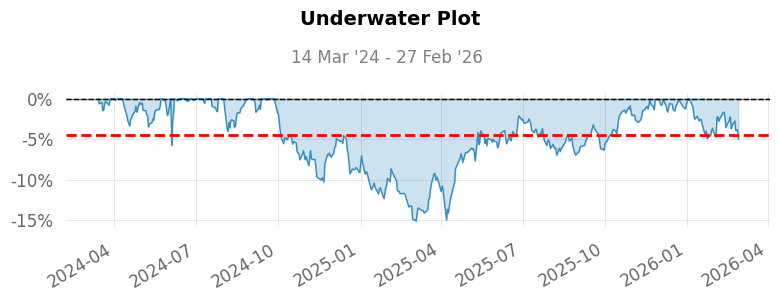

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


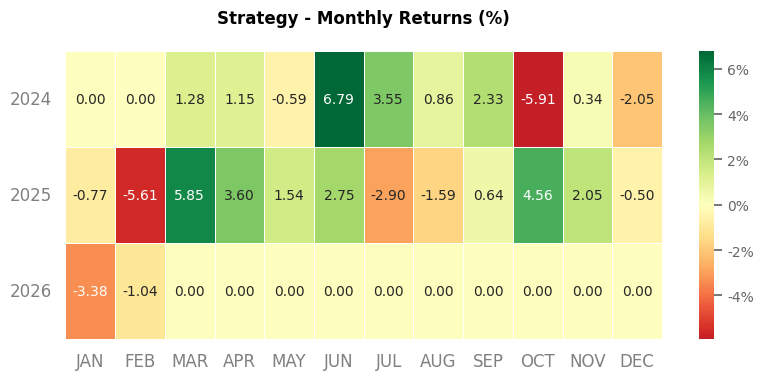

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


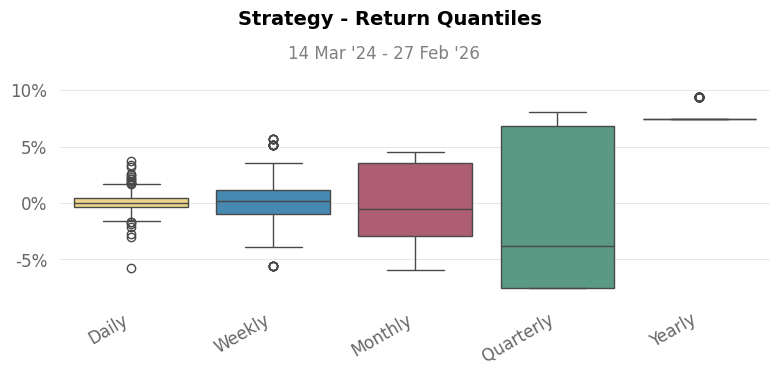

In [ ]:
qs.reports.full(portfolio,stock)

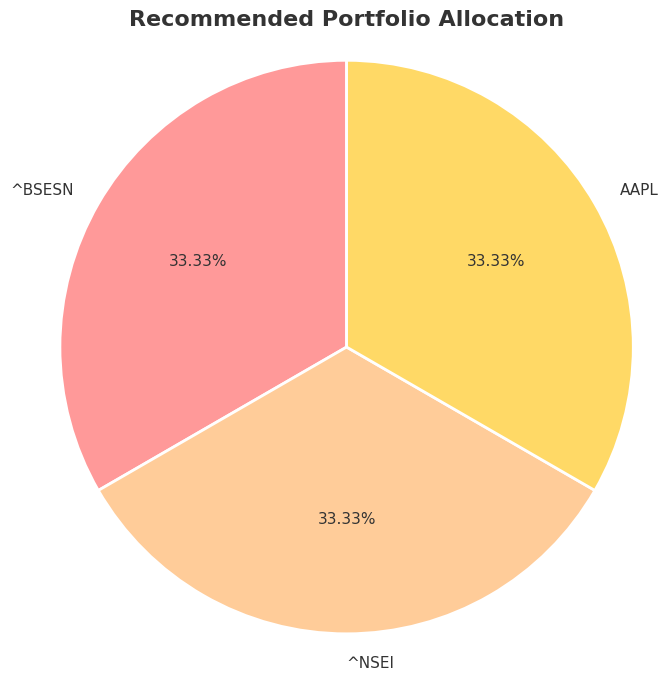

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Weights from model
weights = np.array(action)

# Remove near-zero allocations
mask = weights > 0.001
weights = weights[mask]
tickers = np.array(tickers)[mask]

# Warm colors
colors = ['#ff9999','#ffcc99','#ffd966','#ffb366','#ff8c66'][:len(weights)]

plt.figure(figsize=(7,7))

plt.pie(
    weights,
    labels=tickers,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.6,
    labeldistance=1.1,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11}
)

plt.title("Recommended Portfolio Allocation", fontsize=16, fontweight='bold')

plt.axis('equal')
plt.tight_layout()

plt.show()